In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Check if autoencoder CNN is able to deal with occlusion

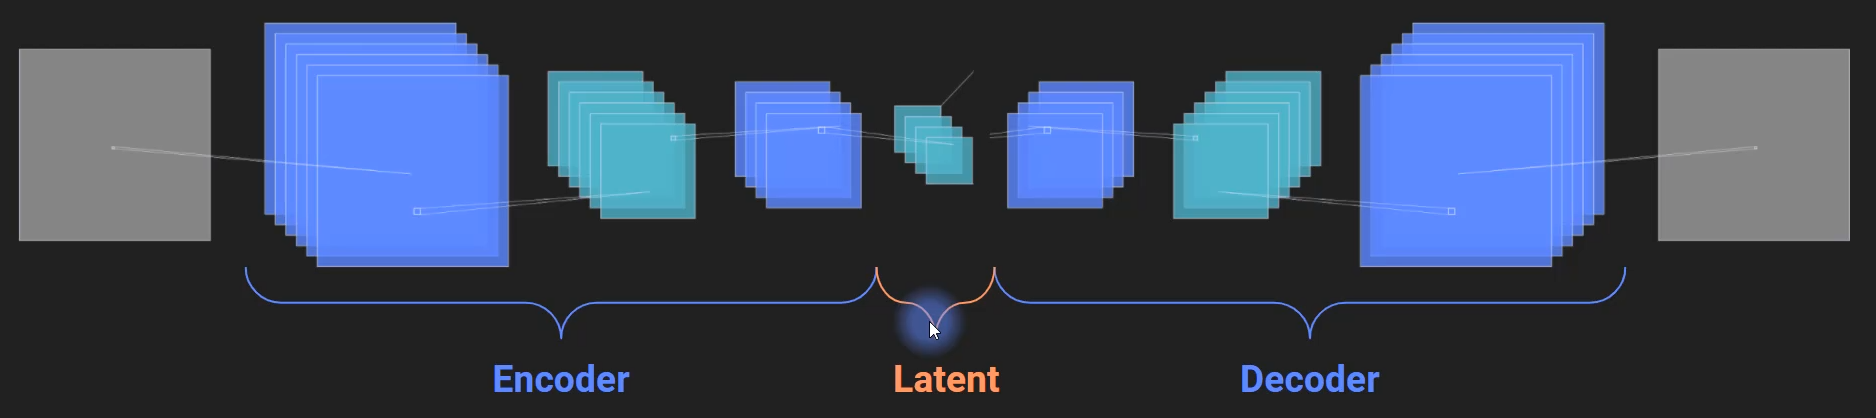

In [1]:
# create a guassian blur with different widths
n_per_class = 1000 # number of samples per class (total samples will be 2*1000 = 2000)
img_size = 91 # size of the images (91x91 pixels)

x = np.linspace(-4, 4, img_size)
X, Y = np.meshgrid(x, x)

class_widths = [1.8, 2.4] # class 0 will have a width of 1.8 and class 1 will have a width of 2.4

occluded_images = torch.zeros((2*n_per_class, 1, img_size, img_size)) # create a tensor to hold the occluded images
clean_images = torch.zeros((2*n_per_class, 1, img_size, img_size)) # create a tensor to hold the clean occluded_images (without occlusion)
labels = torch.zeros(2*n_per_class, dtype=torch.long) # create a tensor to hold the labels

for i in range(2): # for each class
    for j in range(n_per_class): # for each sample in the class
        width = class_widths[i] # get the width for the class
        center = 2*np.random.randn(2) # randomly shift the center of the gaussian blur
        gauss = np.exp(-((X - center[0])**2 + (Y - center[1])**2) / (2 * width**2)) # create a gaussian blur with the given width and center
        gauss = gauss + np.random.randn(img_size, img_size) * 0.2 # add some noise to the image
        
        clean_images[i*n_per_class + j] = torch.tensor(gauss).view(1, img_size, img_size) # store the clean image in the tensor
        
        # add an horizontal or vertical bar of occlusion to the image
        bar_width = np.random.randint(2, 6) # random width of the bar
        starting_point = np.random.randint(2, 28) # random starting point of the bar between 2 and 28
        if np.random.rand() > 0.5: # horizontal bar
            gauss[starting_point:starting_point + bar_width, :] = 1
        else: # vertical bar
            gauss[:, starting_point:starting_point + bar_width] = 1

        occluded_images[i*n_per_class + j] = torch.tensor(gauss).view(1, img_size, img_size) # store the occluded image in the tensor
        labels[i*n_per_class + j] = i # store the label (0 for class 0 and 1 for class 1)

labels = labels.view(-1, 1) # reshape labels to be a column vector

NameError: name 'np' is not defined

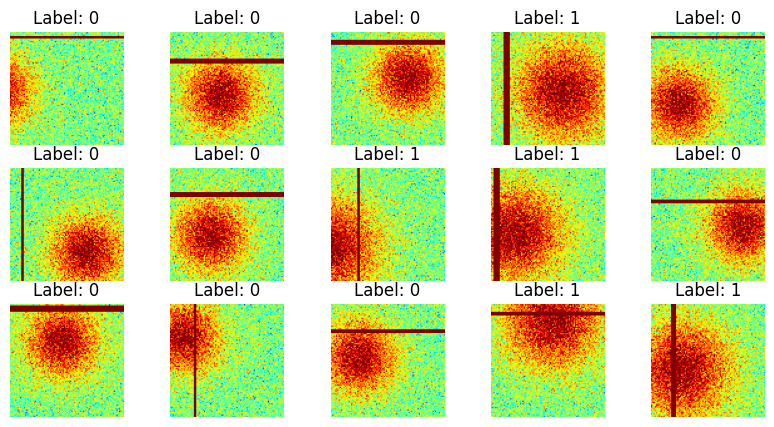

In [3]:
# visualize some occluded_images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    random_pic = np.random.randint(0, 2*n_per_class) # randomly select an image from the dataset
    ax.imshow(occluded_images[random_pic].squeeze(), cmap='jet', vmin=-1, vmax=1)
    ax.set_title(f'Label: {labels[random_pic].item()}')
    ax.axis('off')

In [2]:
# create train and test dataloaders
X_train, X_test, y_train, y_test = train_test_split(occluded_images, labels, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

NameError: name 'train_test_split' is not defined

In [ ]:
class AutoEncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output: (6, 91, 91)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (6, 45, 45)

            nn.Conv2d(in_channels=6, out_channels=4, kernel_size=3, stride=1, padding=1), # output: (4, 45, 45)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (4, 22, 22)
        )

        self.decoder = nn.Sequential(
            # conv tranpose to upsample the image back to the original size
            nn.ConvTranspose2d(in_channels=4, out_channels=6, kernel_size=3, stride=2, padding=0, output_padding=0), # output: (6, 45, 45)
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=6, out_channels=1, kernel_size=3, stride=2, padding=0, output_padding=0), # output: (1, 91, 91)
            nn.Sigmoid() # we want the output to be between 0 and 1 since we are reconstructing the image
            # for CNN autoencoders, the output must have the same range as the input, which is normalized between 0 and 1.
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
model = AutoEncoderCNN()
summary(model, input_size=(1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
          Sigmoid-10            [-1, 1, 91, 91]               0
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.30
Params size (MB): 0.00
Estimated Total Siz

In [3]:
# test the model with a batch of data
# we have to ensure that the input and output shapes are correct before we start training the model, otherwise we might run into errors during training
model = AutoEncoderCNN()
images, labels = next(iter(train_dataloader))
outputs = model(images)
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, images)
print(f"occluded_images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Loss: {loss.item()}")

NameError: name 'AutoEncoderCNN' is not defined

In [28]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    labels_available=False # if False, it will use the input images as labels for the reconstruction task, if True, it will use the labels for a classification task
                    ):
    model.train()
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        if labels_available:
            outputs = model(X)
            loss = loss_fn(outputs, y)
        else:
            X_reconstructed = model(X)
            loss = loss_fn(X_reconstructed, X)
        train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int = 5,
          labels_available=False # if False, it will use the input images as labels for the reconstruction task, if True, it will use the labels for a classification task
          ):

    train_losses_epochs = []
    test_losses_epochs = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_dataloader, loss_fn, optimizer, labels_available)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)

        # Evaluate on the test set
        model.eval()
        test_loss = 0.0

        with torch.no_grad():
            for X, y in test_dataloader:
                if labels_available:
                    outputs = model(X)
                    loss = loss_fn(outputs, y)
                else:
                    X_reconstructed = model(X)
                    loss = loss_fn(X_reconstructed, X)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_dataloader)
        test_losses_epochs.append(avg_test_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Test Loss: {avg_test_loss:.4f}"
        )

    return train_losses_epochs, test_losses_epochs

In [4]:
model = AutoEncoderCNN()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10
train_losses, test_losses = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

NameError: name 'AutoEncoderCNN' is not defined

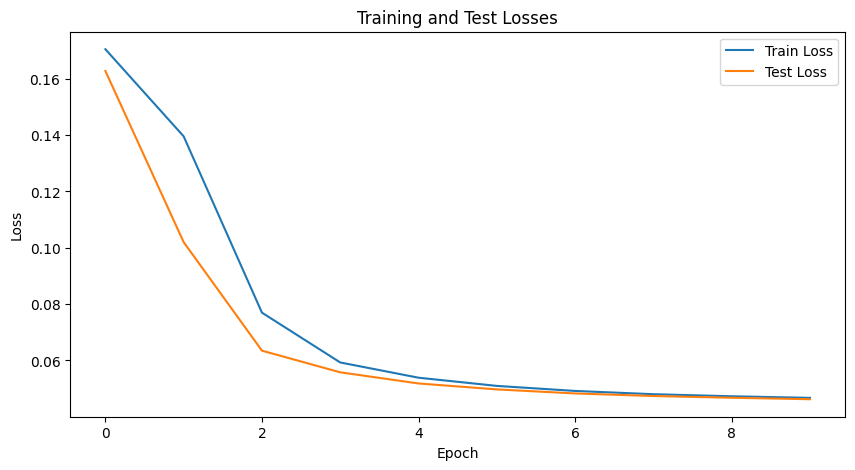

In [9]:
# plot the training and test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Losses')
plt.show()

In [5]:
# Create a 2x5 grid
fig, axs = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    # 1. Select a random image
    random_pic = np.random.randint(0, 32)
    img_tensor = occluded_images[random_pic]
    
    # 2. Get images ready
    original_image = img_tensor.squeeze().numpy()
    reconstructed_image = model(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    
    # 3. Plot Original (Top Row)
    axs[0, i].imshow(original_image, cmap='jet', vmin=-1, vmax=1)
    axs[0, i].set_title(f'Orig (L: {labels[random_pic].item()})')
    axs[0, i].axis('off')
    
    # 4. Plot Reconstruction (Bottom Row)
    axs[1, i].imshow(reconstructed_image, cmap='jet', vmin=-1, vmax=1)
    axs[1, i].set_title('Reconstructed')
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

# so we see that the autoencoder is not able to avoid the oclussion in the images, since the image is reconstructed with the bar


NameError: name 'plt' is not defined

In [6]:
# train it with clean images (without occlusion) and see if it can learn to reconstruct the occluded_images without the occlusion
# we will use the same model and training loop, but we will use the clean_images tensor

train_dataset_clean = TensorDataset(clean_images, labels)
train_dataloader_clean = DataLoader(train_dataset_clean, batch_size=32, shuffle=True, drop_last=True)

model_clean = AutoEncoderCNN()
loss_fn_clean = nn.MSELoss()    
optimizer_clean = torch.optim.Adam(model_clean.parameters(), lr=0.001)
epochs = 10
train_losses_clean, test_losses_clean = train(model_clean, train_dataloader_clean, train_dataloader_clean, loss_fn_clean, optimizer_clean, epochs)

NameError: name 'TensorDataset' is not defined

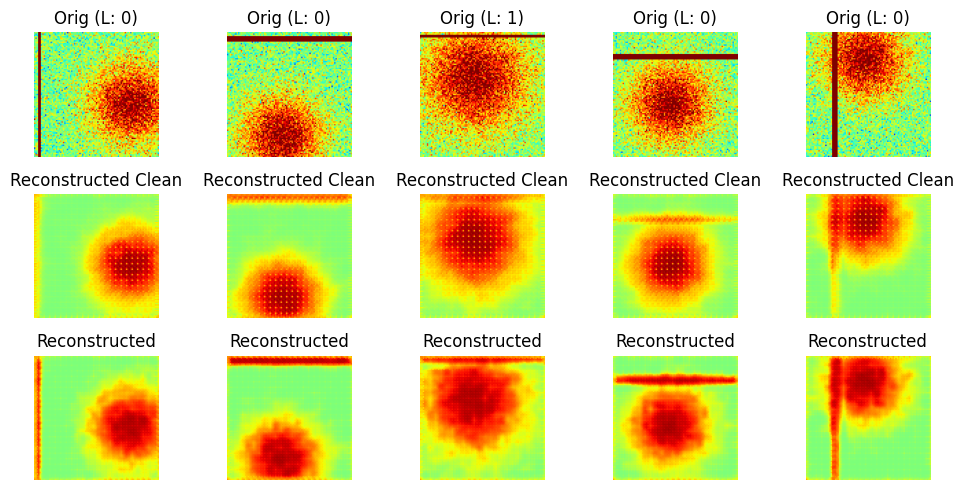

In [20]:
# Create a 2x5 grid
fig, axs = plt.subplots(3, 5, figsize=(10, 5))

for i in range(5):
    # 1. Select a random image
    random_pic = np.random.randint(0, len(occluded_images))
    img_tensor = occluded_images[random_pic]
    
    # 2. Get images ready
    original_image = img_tensor.squeeze().numpy()
    reconstructed_image_clean = model_clean(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    reconstructed_image = model(img_tensor.unsqueeze(0)).squeeze().detach().numpy()

    # 3. Plot Original (Top Row)
    axs[0, i].imshow(original_image, cmap='jet', vmin=-1, vmax=1)
    axs[0, i].set_title(f'Orig (L: {labels[random_pic].item()})')
    axs[0, i].axis('off')
    
    # 4. Plot Reconstruction (Bottom Row)
    axs[1, i].imshow(reconstructed_image_clean, cmap='jet', vmin=-1, vmax=1)
    axs[1, i].set_title('Reconstructed Clean')
    axs[1, i].axis('off')

    axs[2, i].imshow(reconstructed_image, cmap='jet', vmin=-1, vmax=1)
    axs[2, i].set_title('Reconstructed')
    axs[2, i].axis('off')

plt.tight_layout()
plt.show()

# we can see that it doesnt work, the autoencoder trained with clean images is not able to reconstruct the images without the occlusion, since the image is reconstructed with the bar

In [31]:
image1, image2 = next(iter(train_dataloader_occluded))
image1.shape, image2.shape

(torch.Size([32, 1, 91, 91]), torch.Size([32, 1, 91, 91]))

In [32]:
# another approach: use the non-occluded images as targets for the occluded images during training, so the model learns to reconstruct the clean image from the occluded image


train_dataset_occluded = TensorDataset(occluded_images, clean_images)
train_dataloader_occluded = DataLoader(train_dataset_occluded, batch_size=32, shuffle=True, drop_last=True)

model_occluded = AutoEncoderCNN()
loss_fn_occluded = nn.MSELoss()    
optimizer_occluded = torch.optim.Adam(model_occluded.parameters(), lr=0.001)
epochs = 15
# we dont care about the test loss in this, so we can introduce the train twice
train_losses_occluded, test_losses_occluded = train(model_occluded, train_dataloader_occluded, train_dataloader_occluded, loss_fn_occluded, optimizer_occluded, epochs, labels_available=True)

Epoch [1/15], Train Loss: 0.1601, Test Loss: 0.1349
Epoch [2/15], Train Loss: 0.0998, Test Loss: 0.0705
Epoch [3/15], Train Loss: 0.0601, Test Loss: 0.0543
Epoch [4/15], Train Loss: 0.0519, Test Loss: 0.0501
Epoch [5/15], Train Loss: 0.0488, Test Loss: 0.0478
Epoch [6/15], Train Loss: 0.0470, Test Loss: 0.0464
Epoch [7/15], Train Loss: 0.0459, Test Loss: 0.0455
Epoch [8/15], Train Loss: 0.0452, Test Loss: 0.0449
Epoch [9/15], Train Loss: 0.0446, Test Loss: 0.0444
Epoch [10/15], Train Loss: 0.0442, Test Loss: 0.0439
Epoch [11/15], Train Loss: 0.0437, Test Loss: 0.0435
Epoch [12/15], Train Loss: 0.0434, Test Loss: 0.0432
Epoch [13/15], Train Loss: 0.0431, Test Loss: 0.0429
Epoch [14/15], Train Loss: 0.0428, Test Loss: 0.0427
Epoch [15/15], Train Loss: 0.0426, Test Loss: 0.0425


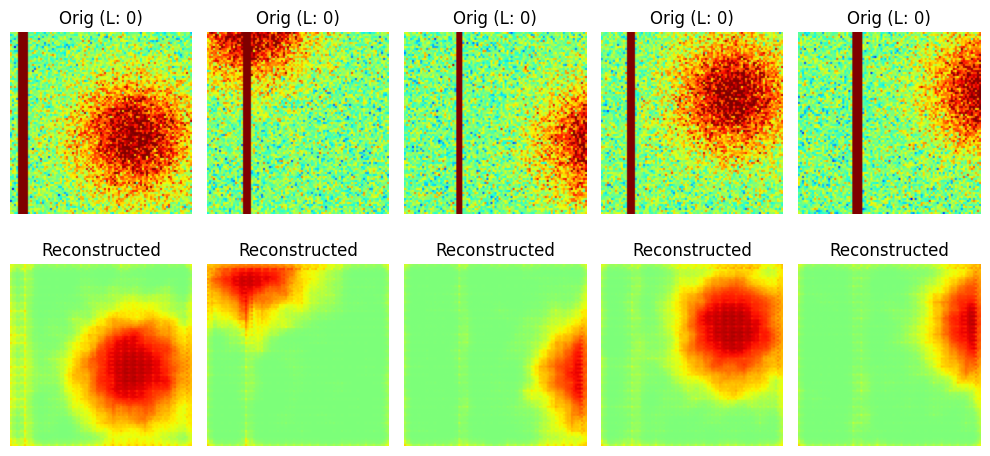

In [ ]:
# plot now the original and the reconstructed with the new model
# Create a 2x5 grid
fig, axs = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    # 1. Select a random image
    random_pic = np.random.randint(0, 32)
    img_tensor = occluded_images[random_pic]
    
    # 2. Get images ready
    original_image = img_tensor.squeeze().numpy()
    reconstructed_image = model_occluded(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    
    # 3. Plot Original (Top Row)
    axs[0, i].imshow(original_image, cmap='jet', vmin=-1, vmax=1)
    axs[0, i].set_title(f'Orig (L: {labels[random_pic].item()})')
    axs[0, i].axis('off')
    
    # 4. Plot Reconstruction (Bottom Row)
    axs[1, i].imshow(reconstructed_image, cmap='jet', vmin=-1, vmax=1)
    axs[1, i].set_title('Reconstructed')
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

#this time we can see that the autoencoder trained with the occluded images and the clean images as targets is able to reconstruct the 
# images without the occlusion, since the image is reconstructed without the bar